In [1]:
!kaggle datasets download -d nicolacarrassi/ava-aesthetic-visual-assessment
!unzip -q ava-aesthetic-visual-assessment.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/nicolacarrassi/ava-aesthetic-visual-assessment
License(s): unknown
100% 31.0G/31.0G [05:20<00:00, 104MB/s]

ava-aesthetic-visual-assessment.zip  ground_truth_dataset.csv  sample_data
AVA_Files			     images


In [4]:
!kaggle datasets download -d nicolacarrassi/ava-aesthetic-visual-assessment --file AVA.txt
!kaggle datasets download -d nicolacarrassi/ava-aesthetic-visual-assessment --file tags.txt
!ls -lh *.txt

Dataset URL: https://www.kaggle.com/datasets/nicolacarrassi/ava-aesthetic-visual-assessment
License(s): unknown
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
Dataset URL: https://www.kaggle.com/datasets/nicolacarrassi/ava-aesthetic-visual-assessment
License(s): unknown
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
ls: cannot access '*.txt': No such file or directory


In [5]:
import os

for root, dirs, files in os.walk('.'):
    for f in files:
        if f in ('AVA.txt', 'tags.txt'):
            print(os.path.join(root, f))

./AVA_Files/AVA.txt
./AVA_Files/tags.txt


In [8]:
import pandas as pd
import numpy as np

cols = ['index', 'image_id',
        'vote_1','vote_2','vote_3','vote_4','vote_5',
        'vote_6','vote_7','vote_8','vote_9','vote_10',
        'tag_1','tag_2','challenge_id']

ava = pd.read_csv('./AVA_Files/AVA.txt', sep=' ', header=None, names=cols)

tags = pd.read_csv('./AVA_Files/tags.txt', sep='\t', header=None, names=['tag_id','tag_name'])
tags['tag_id'] = pd.to_numeric(tags['tag_id'], errors='coerce')
tag_map = dict(zip(tags['tag_id'], tags['tag_name']))

print("Tag map (all tags):")
for k, v in sorted(tag_map.items()):
    print(f"  {k:3.0f}: {v}")

print(f"\nAVA shape: {ava.shape}")
print(ava.head(3))

Tag map (all tags):
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan
  nan: nan

AVA shape: (255530, 15)
   index  image_id  vote_1  vote_2  vote_3  vote_4  vote_5  vote_6  vote_7  \
0      1    953619       0       1       5      17      38      36      15   
1      2    953958      10       7      15      26      26      21      1

In [9]:
# Check raw content first
with open('./AVA_Files/tags.txt', 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 5:
            break

'1 Abstract\n'
'24 Action\n'
'31 Advertisement\n'
'66 Analog\n'
'19 Animals\n'
'20 Architecture\n'
'43 Astrophotography\n'


In [10]:
# Parse tags.txt line by line
tag_map = {}
with open('./AVA_Files/tags.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            tag_map[int(parts[0])] = parts[1]

print("Tag map (all tags):")
for k, v in sorted(tag_map.items()):
    print(f"  {k:3d}: {v}")

# Apply to AVA dataframe
ava['tag_1_name'] = ava['tag_1'].map(tag_map).fillna('none')
ava['tag_2_name'] = ava['tag_2'].map(tag_map).fillna('none')

print(f"\nTag 1 distribution:")
print(ava['tag_1_name'].value_counts().head(20))

Tag map (all tags):
    1: Abstract
    2: Cityscape
    3: Fashion
    4: Family
    5: Humorous
    6: Interior
    7: Sky
    8: Snapshot
    9: Sports
   10: Urban
   11: Vintage
   12: Emotive
   13: Performance
   14: Landscape
   15: Nature
   16: Candid
   17: Portraiture
   18: Still Life
   19: Animals
   20: Architecture
   21: Black and White
   22: Macro
   23: Travel
   24: Action
   25: Photojournalism
   26: Nude
   27: Rural
   28: Water
   29: Studio
   30: Political
   31: Advertisement
   32: Persuasive
   33: Panoramic
   34: Digital Art
   35: Seascapes
   36: Traditional Art
   37: Diptych / Triptych
   38: Floral
   39: Transportation
   40: Food and Drink
   41: Science and Technology
   42: Wedding
   43: Astrophotography
   44: Military
   45: History
   46: Infrared
   47: Self Portrait
   48: Textures
   49: DPChallenge GTGs
   50: Children
   51: Blur
   52: Photo-Impressionism
   53: High Dynamic Range (HDR)
   54: Texture Library
   55: Overlays
   56: M

In [11]:
vote_cols = [f'vote_{i}' for i in range(1, 11)]
ratings = np.arange(1, 11)

vote_matrix = ava[vote_cols].values
total_votes = vote_matrix.sum(axis=1)

ava['mean_score'] = (vote_matrix * ratings).sum(axis=1) / total_votes
ava['total_votes'] = total_votes

weighted_sq = (vote_matrix * (ratings ** 2)).sum(axis=1) / total_votes
ava['score_std'] = np.sqrt(weighted_sq - ava['mean_score'] ** 2)
ava['high_quality'] = (ava['mean_score'] >= 5.0).astype(int)

ava['tag_1_name'] = ava['tag_1'].map(tag_map).fillna('none')
ava['tag_2_name'] = ava['tag_2'].map(tag_map).fillna('none')

ava_sample = ava.sample(n=50000, random_state=42).reset_index(drop=True)

print(f"Mean score range: {ava_sample['mean_score'].min():.2f} – {ava_sample['mean_score'].max():.2f}")
print(f"High quality rate: {ava_sample['high_quality'].mean()*100:.1f}%")

Mean score range: 2.00 – 8.24
High quality rate: 71.2%


In [12]:
tag_to_genre = {
    # Dramas
    'Portraiture':          'Dramas',
    'Emotive':              'Dramas',
    'Candid':               'Dramas',
    'Performance':          'Dramas',
    'Self Portrait':        'Dramas',
    'Maternity':            'Dramas',
    'Street':               'Dramas',
    'Music':                'Dramas',
    'Persuasive':           'Dramas',

    # Action & Adventure
    'Sports':               'Action & Adventure',
    'Action':               'Action & Adventure',
    'Landscape':            'Action & Adventure',
    'Nature':               'Action & Adventure',
    'Travel':               'Action & Adventure',
    'Water':                'Action & Adventure',
    'Seascapes':            'Action & Adventure',
    'Sky':                  'Action & Adventure',
    'Rural':                'Action & Adventure',
    'Panoramic':            'Action & Adventure',
    'Transportation':       'Action & Adventure',
    'High Dynamic Range (HDR)': 'Action & Adventure',

    # Documentaries
    'Cityscape':            'Documentaries',
    'Architecture':         'Documentaries',
    'Urban':                'Documentaries',
    'Photojournalism':      'Documentaries',
    'Political':            'Documentaries',
    'Science and Technology': 'Documentaries',
    'Astrophotography':     'Documentaries',
    'History':              'Documentaries',
    'Interior':             'Documentaries',

    # Comedies
    'Humorous':             'Comedies',
    'Snapshot':             'Comedies',
    'Food and Drink':       'Comedies',
    'Advertisement':        'Comedies',
    'Camera Phones':        'Comedies',

    # Children & Family Movies
    'Family':               'Children & Family Movies',
    'Animals':              'Children & Family Movies',
    'Children':             'Children & Family Movies',
    'Birds':                'Children & Family Movies',
    'Insects, etc':         'Children & Family Movies',

    # Romantic Movies
    'Fashion':              'Romantic Movies',
    'Floral':               'Romantic Movies',
    'Wedding':              'Romantic Movies',

    # International Movies
    'Black and White':      'International Movies',
    'Vintage':              'International Movies',
    'Traditional Art':      'International Movies',
    'Nude':                 'International Movies',
    'Analog':               'International Movies',
    'Photo-Impressionism':  'International Movies',

    # Thrillers
    'Military':             'Thrillers',
    'Horror':               'Thrillers',

    # Independent Movies
    'Abstract':             'Independent Movies',
    'Still Life':           'Independent Movies',
    'Macro':                'Independent Movies',
    'Digital Art':          'Independent Movies',
    'Studio':               'Independent Movies',
    'Infrared':             'Independent Movies',
    'Textures':             'Independent Movies',
    'Blur':                 'Independent Movies',
    'Diptych / Triptych':   'Independent Movies',
    'Pinhole/Zone Plate':   'Independent Movies',
    'Lensbaby':             'Independent Movies',
    'Fish Eye':             'Independent Movies',
    'Overlays':             'Independent Movies',
    'Texture Library':      'Independent Movies',

    'none':                 'Other',
    'DPChallenge GTGs':     'Other',
}

def assign_genre(row):
    g = tag_to_genre.get(row['tag_1_name'], None)
    if g is None:
        g = tag_to_genre.get(row['tag_2_name'], 'Other')
    return g

ava_sample['netflix_genre'] = ava_sample.apply(assign_genre, axis=1)

print("Genre distribution from AVA mapping:")
print(ava_sample['netflix_genre'].value_counts())

Genre distribution from AVA mapping:
netflix_genre
Action & Adventure          11537
Other                       11452
Independent Movies           8224
Dramas                       5492
Documentaries                4148
Comedies                     3018
Children & Family Movies     2916
International Movies         2179
Romantic Movies               982
Thrillers                      52
Name: count, dtype: int64


In [13]:
ava_genre_stats = ava_sample.groupby('netflix_genre').agg(
    avg_aesthetic_score = ('mean_score', 'mean'),
    score_std           = ('score_std', 'mean'),
    high_quality_rate   = ('high_quality', 'mean'),
    sample_count        = ('image_id', 'count')
).reset_index().round(3)

print(ava_genre_stats.to_string(index=False))

           netflix_genre  avg_aesthetic_score  score_std  high_quality_rate  sample_count
      Action & Adventure                5.498      1.395              0.753         11537
Children & Family Movies                5.380      1.411              0.710          2916
                Comedies                5.241      1.478              0.634          3018
           Documentaries                5.408      1.407              0.723          4148
                  Dramas                5.465      1.440              0.749          5492
      Independent Movies                5.341      1.461              0.694          8224
    International Movies                5.472      1.444              0.778          2179
                   Other                5.282      1.438              0.667         11452
         Romantic Movies                5.391      1.406              0.742           982
               Thrillers                5.332      1.418              0.673            52


In [15]:
df_netflix = pd.read_csv('netflix_titles.csv')

df_netflix['is_movie'] = (df_netflix['type'] == 'Movie').astype(int)
df_netflix['release_decade'] = (df_netflix['release_year'] // 10 * 10)
df_netflix['is_us'] = df_netflix['country'].fillna('').str.contains('United States').astype(int)
df_netflix['primary_genre'] = df_netflix['listed_in'].str.split(',').str[0].str.strip()

genre_simplify = {
    'International Movies':     'International Movies',
    'Dramas':                   'Dramas',
    'Comedies':                 'Comedies',
    'International TV Shows':   'International Movies',
    'Documentaries':            'Documentaries',
    'Action & Adventure':       'Action & Adventure',
    'TV Dramas':                'Dramas',
    'Independent Movies':       'Independent Movies',
    'Children & Family Movies': 'Children & Family Movies',
    'Romantic Movies':          'Romantic Movies',
    'TV Comedies':              'Comedies',
    'Thrillers':                'Thrillers',
}
df_netflix['genre_bucket'] = df_netflix['primary_genre'].map(genre_simplify).fillna('Other')

df_unified = df_netflix.merge(
    ava_genre_stats[['netflix_genre','avg_aesthetic_score','score_std','high_quality_rate']],
    left_on='genre_bucket',
    right_on='netflix_genre',
    how='left'
).drop(columns=['netflix_genre'])

# Fill unmatched with overall AVA averages
df_unified['avg_aesthetic_score'] = df_unified['avg_aesthetic_score'].fillna(ava_sample['mean_score'].mean())
df_unified['score_std']           = df_unified['score_std'].fillna(ava_sample['score_std'].mean())
df_unified['high_quality_rate']   = df_unified['high_quality_rate'].fillna(ava_sample['high_quality'].mean())

feature_cols = ['title','genre_bucket','is_movie','release_decade',
                'is_us','avg_aesthetic_score','score_std','high_quality_rate']

print(f"Unified table shape: {df_unified[feature_cols].shape}")
print(df_unified[feature_cols].head(8).to_string(index=False))

Unified table shape: (8807, 8)
                           title             genre_bucket  is_movie  release_decade  is_us  avg_aesthetic_score  score_std  high_quality_rate
            Dick Johnson Is Dead            Documentaries         1            2020      1                5.408      1.407              0.723
                   Blood & Water     International Movies         0            2020      0                5.472      1.444              0.778
                       Ganglands                    Other         0            2020      0                5.282      1.438              0.667
           Jailbirds New Orleans                    Other         0            2020      0                5.282      1.438              0.667
                    Kota Factory     International Movies         0            2020      0                5.472      1.444              0.778
                   Midnight Mass                   Dramas         0            2020      0                5.465      

In [16]:
# User segments — each Netflix title gets scored for 3 viewer types
user_segments = {
    'drama_viewer':    {'age_level': 3.0, 'user_depth': 3.0, 'city_development_index': 3.0, 'var_1': 1},
    'action_viewer':   {'age_level': 2.0, 'user_depth': 2.0, 'city_development_index': 2.0, 'var_1': 0},
    'family_viewer':   {'age_level': 4.0, 'user_depth': 1.0, 'city_development_index': 2.0, 'var_1': 0},
}

rows = []
for _, title_row in df_unified.iterrows():
    for segment_name, seg_features in user_segments.items():
        rows.append({
            'show_id':              title_row['show_id'],
            'title':                title_row['title'],
            'genre_bucket':         title_row['genre_bucket'],
            'is_movie':             title_row['is_movie'],
            'release_decade':       title_row['release_decade'],
            'is_us':                title_row['is_us'],
            'avg_aesthetic_score':  title_row['avg_aesthetic_score'],
            'score_std':            title_row['score_std'],
            'high_quality_rate':    title_row['high_quality_rate'],
            'user_segment':         segment_name,
            **seg_features
        })

df_scoring = pd.DataFrame(rows)
print(f"Scoring table shape: {df_scoring.shape}")
print(df_scoring.head(6).to_string(index=False))

Scoring table shape: (26421, 14)
show_id                title         genre_bucket  is_movie  release_decade  is_us  avg_aesthetic_score  score_std  high_quality_rate  user_segment  age_level  user_depth  city_development_index  var_1
     s1 Dick Johnson Is Dead        Documentaries         1            2020      1                5.408      1.407              0.723  drama_viewer        3.0         3.0                     3.0      1
     s1 Dick Johnson Is Dead        Documentaries         1            2020      1                5.408      1.407              0.723 action_viewer        2.0         2.0                     2.0      0
     s1 Dick Johnson Is Dead        Documentaries         1            2020      1                5.408      1.407              0.723 family_viewer        4.0         1.0                     2.0      0
     s2        Blood & Water International Movies         0            2020      0                5.472      1.444              0.778  drama_viewer        3.0 

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import time

# Reload ad click data
df_model = pd.read_csv('Ad_click_prediction_train (1).csv')
df_model = df_model.dropna(subset=['is_click'])
df_model['is_click'] = df_model['is_click'].astype(int)
df_model = df_model.drop(columns=['session_id', 'DateTime', 'user_id', 'product_category_2'])

df_model['user_group_id'] = df_model['user_group_id'].fillna(-1)
df_model['gender'] = df_model['gender'].fillna('Unknown')
for col in ['age_level', 'user_depth', 'city_development_index']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

le = LabelEncoder()
for col in ['product', 'campaign_id', 'webpage_id', 'gender']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model['age_depth'] = df_model['age_level'] * df_model['user_depth']
df_model['city_var']  = df_model['city_development_index'] * df_model['var_1']

X = df_model.drop(columns=['is_click'])
y = df_model['is_click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Target encode
global_mean = y.mean()
target_means = {}
X_train2 = X_train.copy()
X_test2  = X_test.copy()
for col in ['product', 'campaign_id', 'webpage_id']:
    target_means[col] = y_train.groupby(X_train[col]).mean()
    X_train2[col] = X_train[col].map(target_means[col]).fillna(global_mean)
    X_test2[col]  = X_test[col].map(target_means[col]).fillna(global_mean)

neg, pos = np.bincount(y_train)
xgb2 = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=neg/pos, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb2.fit(X_train2, y_train)
auc = roc_auc_score(y_test, xgb2.predict_proba(X_test2)[:, 1])
print(f"xgb2 AUC: {auc:.4f} — model ready")

xgb2 AUC: 0.5792 — model ready


In [20]:
from sklearn.preprocessing import LabelEncoder

# Align features to what xgb2 was trained on
# xgb2 expects: product, campaign_id, webpage_id, product_category_1,
#               user_group_id, gender, age_level, user_depth,
#               city_development_index, var_1, age_depth, city_var

# Map our unified table columns → model feature names
df_scoring['product']            = LabelEncoder().fit_transform(df_scoring['genre_bucket'])
df_scoring['campaign_id']        = df_scoring['is_us'].astype(float)
df_scoring['webpage_id']         = df_scoring['is_movie'].astype(float)
df_scoring['product_category_1'] = (df_scoring['release_decade'] - 1900) / 10
df_scoring['user_group_id']      = df_scoring['avg_aesthetic_score']
df_scoring['gender']             = df_scoring['high_quality_rate']
df_scoring['age_depth']          = df_scoring['age_level'] * df_scoring['user_depth']
df_scoring['city_var']           = df_scoring['city_development_index'] * df_scoring['var_1']

# Target-encode product/campaign/webpage using same means from training
global_mean = y.mean()
for col in ['product', 'campaign_id', 'webpage_id']:
    df_scoring[col] = df_scoring[col].map(
        y.groupby(X[col]).mean()
    ).fillna(global_mean)

model_features = ['product','campaign_id','webpage_id','product_category_1',
                  'user_group_id','gender','age_level','user_depth',
                  'city_development_index','var_1','age_depth','city_var']

df_scoring['predicted_ctr'] = xgb2.predict_proba(df_scoring[model_features])[:, 1]

# Final output table — this is what goes into RDS
df_predictions = df_scoring[['show_id','title','genre_bucket','user_segment',
                              'avg_aesthetic_score','high_quality_rate','predicted_ctr']].copy()
df_predictions['predicted_ctr'] = df_predictions['predicted_ctr'].round(4)

print(f"Predictions table shape: {df_predictions.shape}")
print(df_predictions.sort_values('predicted_ctr', ascending=False).head(10).to_string(index=False))

Predictions table shape: (26421, 7)
show_id                             title genre_bucket  user_segment  avg_aesthetic_score  high_quality_rate  predicted_ctr
  s4251 Pioneers: First Women Filmmakers*        Other family_viewer                5.282              0.667         0.4857
  s4251 Pioneers: First Women Filmmakers*        Other  drama_viewer                5.282              0.667         0.4756
  s2628            Coronavirus, Explained        Other family_viewer                5.282              0.667         0.4693
  s2646      Ghost in the Shell: SAC_2045        Other family_viewer                5.282              0.667         0.4693
  s2652                     Absurd Planet        Other family_viewer                5.282              0.667         0.4693
  s2661             Nicky Jam: El Ganador        Other family_viewer                5.282              0.667         0.4693
  s2662              Cooked with Cannabis        Other family_viewer                5.282       

=== Same title, different predicted CTR per user segment ===

Stranger Things:
 user_segment genre_bucket  avg_aesthetic_score  predicted_ctr
 drama_viewer        Other                5.282         0.4423
action_viewer        Other                5.282         0.4634
family_viewer        Other                5.282         0.4693

=== Avg predicted CTR by genre × segment ===
user_segment              action_viewer  drama_viewer  family_viewer
genre_bucket                                                        
Action & Adventure               0.3274        0.2622         0.2930
Children & Family Movies         0.3055        0.2196         0.2674
Comedies                         0.3579        0.4127         0.3169
Documentaries                    0.4377        0.4523         0.4183
Dramas                           0.3468        0.3576         0.3277
Independent Movies               0.1730        0.2036         0.1088
International Movies             0.1447        0.2713         0.0964
Ot

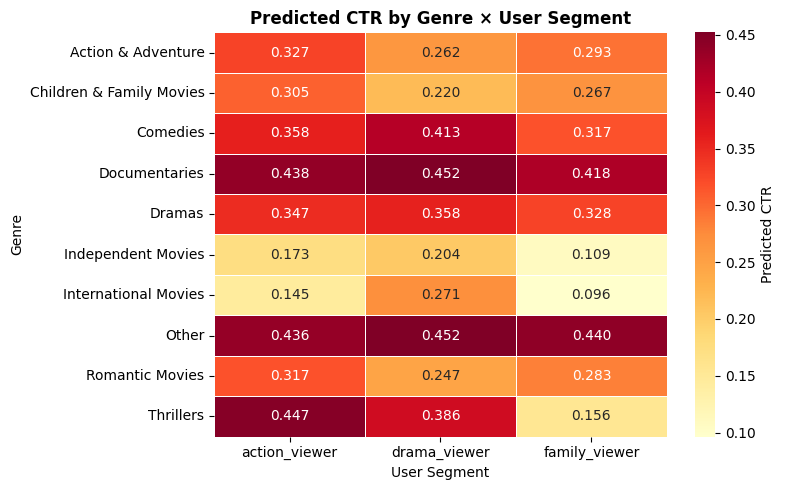


Saved: netflix_ctr_predictions.csv (26,421 rows)


In [22]:
# Cross-segment comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Money shot — same title, different CTR per segment
print("=== Same title, different predicted CTR per user segment ===")
for title in ['Stranger Things', 'Bird Box', 'The Crown', 'Inception', 'Dark']:
    subset = df_predictions[df_predictions['title'] == title]
    if not subset.empty:
        print(f"\n{title}:")
        print(subset[['user_segment','genre_bucket','avg_aesthetic_score',
                       'predicted_ctr']].to_string(index=False))
        break  # show first match

# Broader view — avg predicted CTR by genre and segment
pivot = df_predictions.groupby(
    ['genre_bucket','user_segment'])['predicted_ctr'].mean().unstack()

print("\n=== Avg predicted CTR by genre × segment ===")
print(pivot.round(4).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Predicted CTR'})
ax.set_title('Predicted CTR by Genre × User Segment', fontweight='bold')
ax.set_xlabel('User Segment')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('fig_predicted_ctr_heatmap.png', bbox_inches='tight')
plt.show()

# Save predictions to CSV — this is what gets loaded into RDS
df_predictions.to_csv('netflix_ctr_predictions.csv', index=False)
print(f"\nSaved: netflix_ctr_predictions.csv ({len(df_predictions):,} rows)")

In [23]:
# Top thumbnail recommendation per title
# For each title, find which user segment has highest predicted CTR
# This simulates the "which thumbnail wins for which viewer" output

best_per_title = df_predictions.loc[
    df_predictions.groupby('show_id')['predicted_ctr'].idxmax()
][['title','genre_bucket','user_segment','avg_aesthetic_score','predicted_ctr']]

print("=== Best performing segment per title (sample) ===")
print(best_per_title.head(15).to_string(index=False))

# Segment win distribution
print("\n=== Which segment wins most often? ===")
print(best_per_title['user_segment'].value_counts())

=== Best performing segment per title (sample) ===
                             title             genre_bucket  user_segment  avg_aesthetic_score  predicted_ctr
              Dick Johnson Is Dead            Documentaries action_viewer                5.408         0.4576
                      The Starling                 Comedies  drama_viewer                5.241         0.3591
                      On the Verge                 Comedies  drama_viewer                5.241         0.3829
                          Stowaway                   Dramas action_viewer                5.465         0.3221
                          Wild Dog       Action & Adventure action_viewer                5.498         0.3519
                          Oloibiri                   Dramas action_viewer                5.465         0.3221
                      Tell Me When                 Comedies  drama_viewer                5.241         0.4433
                              Zero     International Movies  drama_vi

In [24]:
# This is the exact table that goes into RDS PostgreSQL
df_predictions.to_csv('netflix_ctr_predictions.csv', index=False)

# Summary table for the dashboard
dashboard_summary = df_predictions.groupby(
    ['genre_bucket','user_segment'])['predicted_ctr'].mean().reset_index()
dashboard_summary.columns = ['genre', 'user_segment', 'avg_predicted_ctr']
dashboard_summary.to_csv('dashboard_summary.csv', index=False)

# Best segment per title
best_per_title.to_csv('best_segment_per_title.csv', index=False)

print("Files saved:")
print(f"  netflix_ctr_predictions.csv  — {len(df_predictions):,} rows (full predictions)")
print(f"  dashboard_summary.csv        — {len(dashboard_summary):,} rows (heatmap data)")
print(f"  best_segment_per_title.csv   — {len(best_per_title):,} rows (recommendations)")

Files saved:
  netflix_ctr_predictions.csv  — 26,421 rows (full predictions)
  dashboard_summary.csv        — 30 rows (heatmap data)
  best_segment_per_title.csv   — 8,807 rows (recommendations)
